In [1]:
!pip install torch transformers scikit-learn pandas tqdm emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.9 MB/s eta 0:00:00


In [2]:
!pip install git+https://github.com/trent-b/iterative-stratification.git

  Cloning https://github.com/trent-b/iterative-stratification.git to /tmp/pip-req-build-j6e81xhr
  Running command git clone --filter=blob:none --quiet https://github.com/trent-b/iterative-stratification.git /tmp/pip-req-build-j6e81xhr
  Resolved https://github.com/trent-b/iterative-stratification.git to commit c763bd5440e5f03c6447471305897c1046fc4838
  Preparing metadata (setup.py) ... done
  Created wheel for iterative-stratification: filename=iterative_stratification-0.1.9-py3-none-any.whl size=8444 sha256=b2066d06baffbece54e08f4cc36a4243221969c94f92d82ed2fb8aefd40a7929
  Stored in directory: /tmp/pip-ephem-wheel-cache-41w5bitt/wheels/1a/53/b5/f5f9836cdfff718e36f6af0df976157168f38b5ce6bf53a49d
Successfully built iterative-stratification


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from torch.optim import AdamW
from tqdm import tqdm
import os
from google.colab import files
import torch, random, numpy as np

In [19]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

In [20]:
uploaded = files.upload()

Saving GoEmotions_uniqueannotations_cleaned_merged_dataset.csv to GoEmotions_uniqueannotations_cleaned_merged_dataset (1).csv


In [21]:
# ----------------------
# 1. Load CSV
# ----------------------
df = pd.read_csv("GoEmotions_uniqueannotations_cleaned_merged_dataset.csv")
# Get emotion columns (excluding 'text')
emotion_cols = df.columns[3:]  # adjust if your labels start elsewhere

# Remove rows where neutral = 1 and all other labels = 0
df = df[~((df['neutral'] == 1) & (df[emotion_cols].drop('neutral', axis=1).sum(axis=1) == 0))]

# Drop the neutral column entirely
df = df.drop(columns=['neutral'])

# Extract texts and labels
texts = df['text'].values
labels = df[df.columns[3:]].values  # after 9th col are binary emotions (now without neutral)
label_names = df.columns[3:].tolist()
num_labels = len(label_names)

# Tokenizer
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

#tae898/emoberta-base


# Add extra columns: word count and token count
def count_words_and_tokens(text):
    words = len(text.split())
    tokens = len(tokenizer.encode(text, add_special_tokens=True))
    return words, tokens

df[["word_count", "token_count"]] = df["text"].apply(lambda x: pd.Series(count_words_and_tokens(x)))
print("Sample rows with new columns:")
print(df.head())

# Count texts containing emojis
emoji_texts = sum(any(char in emoji.EMOJI_DATA for char in t) for t in texts)
print(f"Number of texts containing emojis: {emoji_texts}")

# Emoji handling function
def preprocess_text(text):
    if any(char in emoji.EMOJI_DATA for char in text):
        text = emoji.demojize(text)
    return text

texts = np.array([preprocess_text(t) for t in texts])

# Class distribution
label_counts = np.sum(labels, axis=0)
print("Class distribution (counts per label):")
for name, c in zip(label_names, label_counts):
    print(f"{name}: {c}")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1437 > 512). Running this sequence through the model will result in indexing errors


Sample rows with new columns:
        id                                               text  \
0  ee3fxil   "If you don't wear BROWN AND ORANGE...YOU DON...   
1  ee7cu0z   "What do Scottish people look like?" How I wo...   
2  edglo8q     ### A surprise, to be sure, but a welcome one    
5  eemcysk   >sexuality shouldn’t be a grouping category I...   
6  edh30hb   And not all children's hospitals need the sam...   

   example_very_unclear  admiration  amusement  anger  annoyance  approval  \
0                 False           0          0      1          1         1   
1                 False           0          0      0          0         0   
2                 False           0          0      0          0         0   
5                 False           0          0      0          0         0   
6                 False           0          0      0          0         1   

   caring  confusion  ...  nervousness  optimism  pride  realization  relief  \
0       0          0  ...     

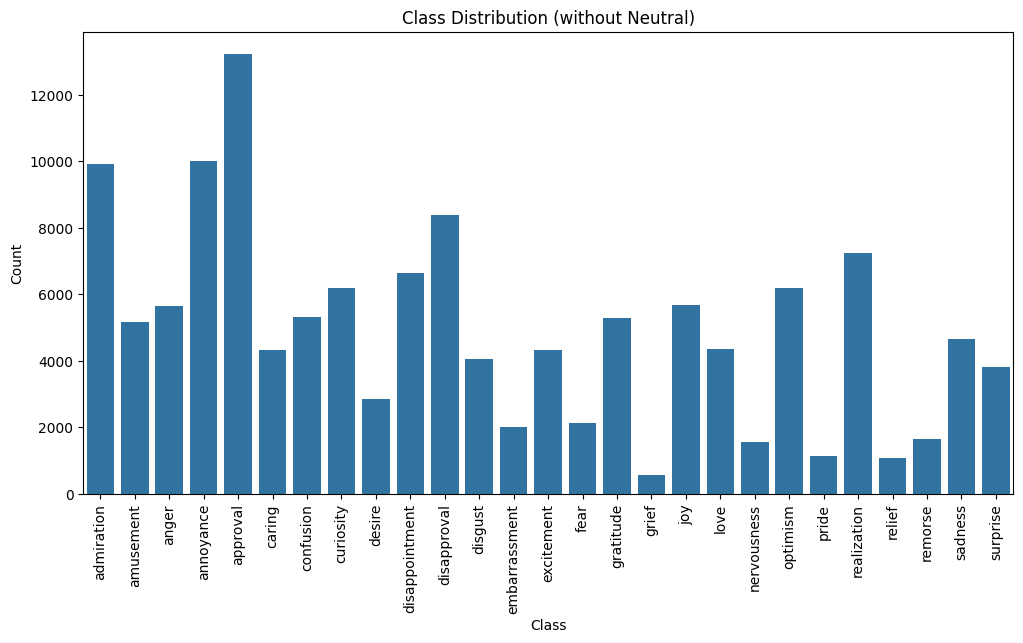

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x=label_names, y=label_counts)
plt.xticks(rotation=90)
plt.title("Class Distribution (without Neutral)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [23]:
print("Total number of emotion labels:", num_labels)
print("Max token count:",max(df["token_count"]))
print("Max word count:", max(df["word_count"]))
print()
second_max_token = df["token_count"].nlargest(2).iloc[-1]
print("second_max_token:",second_max_token)

third_max_token = df["token_count"].nlargest(3).iloc[-1]
print("third_max_token:",third_max_token)

fourth_max_token = df["token_count"].nlargest(4).iloc[-1]
print("fourth_max_token:",fourth_max_token)

fifth_max_token = df["token_count"].nlargest(5).iloc[-1]
print("fifth_max_token:",fifth_max_token)

tenth_max_token = df["token_count"].nlargest(10).iloc[-1]
print("tenth_max_token:",tenth_max_token)

twentieth_max_token = df["token_count"].nlargest(20).iloc[-1]
print("twentieth_max_token:",twentieth_max_token)

hundredth_max_token = df["token_count"].nlargest(100).iloc[-1]
print("hundredth_max_token:",hundredth_max_token)


Total number of emotion labels: 27
Max token count: 1437
Max word count: 33

second_max_token: 186
third_max_token: 167
fourth_max_token: 106
fifth_max_token: 97
tenth_max_token: 65
twentieth_max_token: 53
hundredth_max_token: 42


In [24]:
class GoEmotionsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': label
        }

In [25]:
# Train/Val/Test split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(texts, labels))
texts_train, texts_test = texts[train_idx], texts[test_idx]
labels_train, labels_test = labels[train_idx], labels[test_idx]

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(msss_val.split(texts_train, labels_train))
texts_train, texts_val = texts_train[train_idx], texts_train[val_idx]
labels_train, labels_val = labels_train[train_idx], labels_train[val_idx]

train_dataset = GoEmotionsDataset(texts_train, labels_train, tokenizer)
val_dataset = GoEmotionsDataset(texts_val, labels_val, tokenizer)
test_dataset = GoEmotionsDataset(texts_test, labels_test, tokenizer)

def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Train size:", len(texts_train))
print("Val size:", len(texts_val))
print("Test size:", len(texts_test))

Train size: 38506
Val size: 4291
Test size: 10693


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.25, reduction='mean'):
        """
        alpha : weighting factor for positive vs negative class
        gamma : focusing parameter to reduce loss for well-classified examples
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits : raw model outputs (before sigmoid)
        targets: binary labels (0/1), same shape as logits
        """
        probs = torch.sigmoid(logits)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [27]:
# Model setup
device = (
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("xla") if "xla" in torch.backends.__dict__ and torch.backends.xla.is_available() else
    torch.device("cpu")
)

config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    dropout = 0.0
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)

model.to(device)

epochs = 5
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.1)
criterion = FocalLoss(alpha=1, gamma=2.25, reduction='mean')

num_training_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * num_training_steps), num_training_steps=num_training_steps)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
# Training + Validation loop

best_val_f1 = 0.0
best_model_state = None

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)
            val_loss += loss.item()
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)
    preds = np.array(preds) > 0.5
    val_f1 = f1_score(true_labels, preds, average="micro")
    val_acc = accuracy_score(true_labels, preds)
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()

model.load_state_dict(best_model_state)
print(f"\nBest validation F1 after {epochs} epochs: {best_val_f1:.4f}")


Epoch 1/5


100%|██████████| 2407/2407 [07:59<00:00,  5.02it/s]


Train Loss: 0.0555 | Val Loss: 0.0451
Val Accuracy: 0.1559 | Val F1: 0.4666

Epoch 2/5


100%|██████████| 2407/2407 [07:59<00:00,  5.02it/s]


Train Loss: 0.0439 | Val Loss: 0.0438
Val Accuracy: 0.1624 | Val F1: 0.5127

Epoch 3/5


...

Train Loss: 0.0401 | Val Loss: 0.0440
Val Accuracy: 0.1678 | Val F1: 0.5192

Epoch 4/5


100%|██████████| 2407/2407 [08:00<00:00,  5.01it/s]


Train Loss: 0.0364 | Val Loss: 0.0450
Val Accuracy: 0.1664 | Val F1: 0.5330

Epoch 5/5


100%|██████████| 2407/2407 [08:00<00:00,  5.01it/s]


Train Loss: 0.0333 | Val Loss: 0.0461
Val Accuracy: 0.1617 | Val F1: 0.5337

Best validation F1 after 5 epochs: 0.5337


In [29]:
# Test loop
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        test_preds.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds = (torch.tensor(np.array(test_preds)) >= 0.5).int()
test_labels = torch.tensor(np.array(test_labels)).int()
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='micro')
print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
test_precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
test_recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")
cm = confusion_matrix(test_labels.view(-1), test_preds.view(-1))
print("Confusion Matrix (flattened across all labels):")
print(cm)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))


Test Acc: 0.1588, Test F1: 0.5273
Test Precision: 0.6242, Test Recall: 0.4564
Confusion Matrix (flattened across all labels):
[[254670   7337]
 [ 14515  12189]]

Detailed Classification Report:
                precision    recall  f1-score   support

    admiration       0.72      0.64      0.68      1982
     amusement       0.81      0.69      0.74      1036
         anger       0.59      0.50      0.54      1129
     annoyance       0.54      0.40      0.46      2005
      approval       0.58      0.40      0.47      2647
        caring       0.56      0.42      0.48       866
     confusion       0.57      0.45      0.50      1062
     curiosity       0.69      0.69      0.69      1241
        desire       0.62      0.39      0.48       568
disappointment       0.52      0.30      0.38      1331
   disapproval       0.60      0.41      0.49      1680
       disgust       0.53      0.36      0.43       811
 embarrassment       0.52      0.18      0.27       401
    excitement       

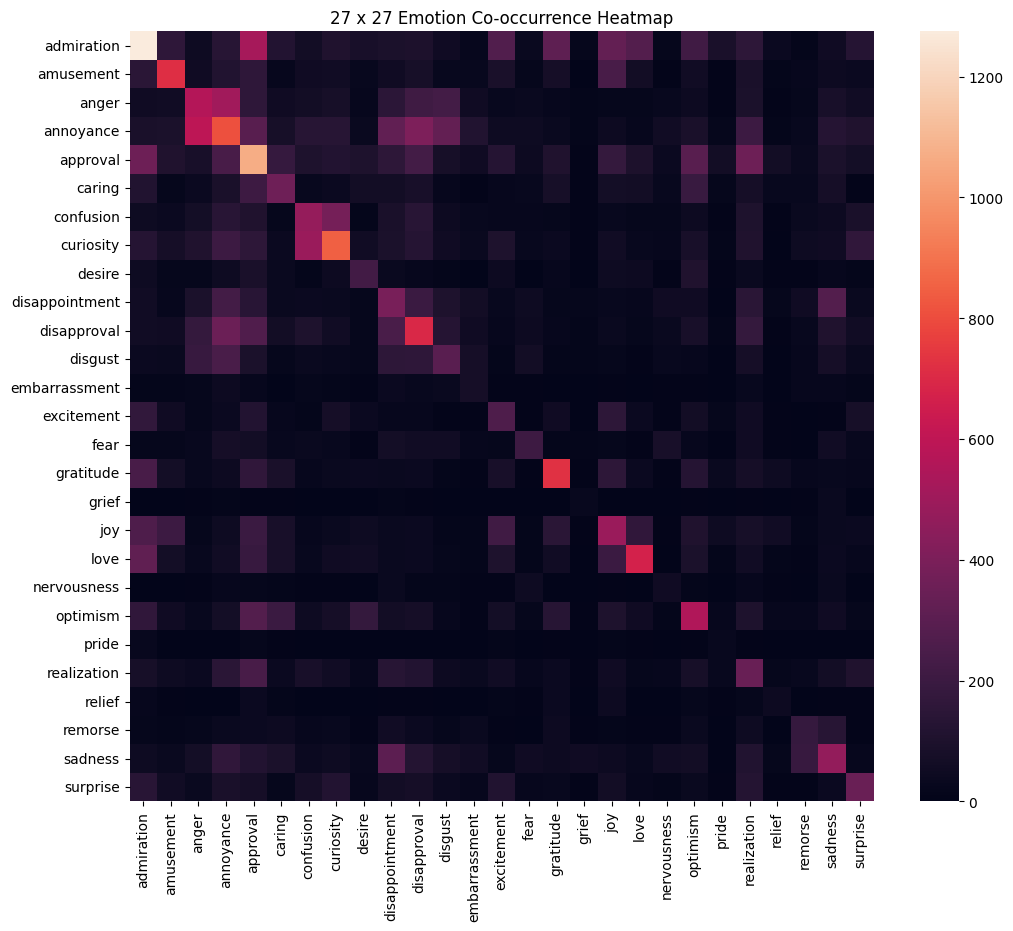

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(test_labels.numpy(), test_preds.numpy())

# sum across TN/FP/FN/TP if you want a 27 x 27 style heatmap of co-predictions
heatmap_data = np.zeros((27, 27))
for i in range(27):
    for j in range(27):
        # approximate co-occurrence in predictions vs true
        heatmap_data[i, j] = ((test_preds[:, i] == 1) & (test_labels[:, j] == 1)).sum()

plt.figure(figsize=(12,10))
sns.heatmap(heatmap_data, xticklabels=label_names, yticklabels=label_names, cmap='rocket', annot=False)
plt.title("27 x 27 Emotion Co-occurrence Heatmap")
plt.show()


In [39]:
# Prediction function
def predict_emotions(text, top_k=5):
    model.eval()
    encoding = tokenizer(text, truncation=True, padding='max_length', max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    top_indices = probs.argsort()[-top_k:][::-1]
    return [(label_names[i], float(probs[i])) for i in top_indices]

user_text = input("Enter a text: ")
print("\nUser Input:", user_text)
print("Predicted Emotions:")
for label, score in predict_emotions(user_text):
    print(f"{label}: {score:.4f}")

Enter a text: I’m tired of pretending I’m fine with everything, yet the moment you look even slightly upset, something in me drops everything just to make sure you’re okay. It irritates me how much I still care, but it also scares me how empty things feel when you’re distant. I don’t even know whether I want to yell at you or just sit next to you quietly like nothing ever went wrong

User Input: I’m tired of pretending I’m fine with everything, yet the moment you look even slightly upset, something in me drops everything just to make sure you’re okay. It irritates me how much I still care, but it also scares me how empty things feel when you’re distant. I don’t even know whether I want to yell at you or just sit next to you quietly like nothing ever went wrong
Predicted Emotions:
nervousness: 0.6253
sadness: 0.5736
fear: 0.5529
caring: 0.5511
disappointment: 0.5486


In [ ]:
# Save & download model
model.save_pretrained("goemotions_distilroberta")
tokenizer.save_pretrained("goemotions_distilroberta")
!zip -r goemotions_distilroberta.zip goemotions_distilroberta
files.download("goemotions_roberta.zip")
# Reload model from uploaded zip
# uploaded = files.upload()
# !unzip -o goemotions_distilroberta.zip -d ./
# loaded_model = DistilRobertaForSequenceClassification.from_pretrained("goemotions_distilroberta")
# loaded_tokenizer = RobertaTokenizer.from_pretrained("goemotions_distilroberta")

updating: goemotions_distilroberta/ (stored 0%)
updating: goemotions_distilroberta/merges.txt (deflated 53%)
updating: goemotions_distilroberta/special_tokens_map.json (deflated 52%)
updating: goemotions_distilroberta/vocab.json (deflated 59%)
updating: goemotions_distilroberta/config.json (deflated 65%)
updating: goemotions_distilroberta/tokenizer.json (deflated 82%)
updating: goemotions_distilroberta/model.safetensors (deflated 10%)
updating: goemotions_distilroberta/tokenizer_config.json (deflated 75%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bringing RoBERTa again, from zip file

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "./goemotions_combined_roberta"   # path to extracted folder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

model.to(device)
model.eval()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [16]:
label_names = [
    "admiration","amusement","anger","annoyance","approval","caring",
    "confusion","curiosity","desire","disappointment","disapproval",
    "disgust","embarrassment","excitement","fear","gratitude","grief",
    "joy","love","nervousness","optimism","pride","realization","relief",
    "remorse","sadness","surprise"
]

In [12]:
import numpy as np

def predict_top5(text):
    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.sigmoid(outputs.logits)[0].cpu().numpy()

    top_idx = probs.argsort()[-5:][::-1]
    return [(label_names[i], float(probs[i])) for i in top_idx]


In [15]:
text = input("Enter text: ")
print(text)
for label, score in predict_top5(text):
    print(f"{label}: {score:.4f}")

Enter a text: I’m tired of pretending I’m fine with everything, yet the moment you look even slightly upset, something in me drops everything just to make sure you’re okay. It irritates me how much I still care, but it also scares me how empty things feel when you’re distant. I don’t even know whether I want to yell at you or just sit next to you quietly like nothing ever went wrong
nervousness: 0.6319
annoyance: 0.5687
fear: 0.5567
sadness: 0.5398
disappointment: 0.5326


In [ ]:
I’m tired of pretending I’m fine with everything, yet the moment you look even slightly upset, something in me drops everything just to make sure you’re okay. It irritates me how much I still care, but it also scares me how empty things feel when you’re distant. I don’t even know whether I want to yell at you or just sit next to you quietly like nothing ever went wrong